# SETUP AND LOAD

In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [2]:
file_path='/kaggle/input/datasets/abdullahmeo/meezan-bank-international-transactions-dataset/meezan_international_transactions (1).csv'
my_dataset=pd.read_csv(file_path)

my_dataset.head()

,Transaction_ID,Customer_ID,Transaction_Type,Source_Country,Destination_Country,Source_City,Destination_City,Source_Currency,Destination_Currency,Exchange_Rate,...,Sharia_Compliant,Contract_Type,Transaction_Date,Transaction_Time,Processing_Time_Seconds,Fraud_Flag,AML_Flag,Risk_Score,Channel,Device_Type
0,TXN000001,CUST7258,Remittance,UK,UK,Manchester,Manchester,GBP,GBP,1.00,...,Yes,Salam,2024-06-20,18:36:02.049355,60.82,0,0,12,Online Portal,Mobile
1,TXN000002,CUST2171,Online Transfer,USA,Saudi Arabia,New York,Jeddah,USD,SAR,207.59,...,Yes,Ijara,2026-03-22,00:48:48.467010,32.48,0,0,10,Branch,Mobile
2,TXN000003,CUST3890,Trade Finance,Saudi Arabia,UAE,Jeddah,Dubai,SAR,AED,161.32,...,Yes,Salam,2024-07-23,10:05:17.988990,61.92,0,0,1,Branch,Desktop
3,TXN000004,CUST4874,SWIFT,UAE,Pakistan,Abu Dhabi,Lahore,AED,PKR,75.00,...,Yes,Salam,2025-07-06,07:28:14.039462,98.73,0,0,3,Mobile App,ATM
4,TXN000005,CUST4343,SWIFT,Saudi Arabia,Pakistan,Riyadh,Lahore,SAR,PKR,74.00,...,Yes,Salam,2025-01-26,02:36:27.820677,28.88,0,0,22,Branch,ATM


# DATA QUALITY CHECK

In [3]:
my_dataset.Transaction_Type.describe()

count          15000
unique             4
top       Remittance
freq            3781
Name: Transaction_Type, dtype: object

In [4]:
#Initial inspection revealed missing values in Contract Type and constant column(s).
#check how many contract types are present
my_dataset.Contract_Type.value_counts()

Contract_Type
Murabaha    3837
Ijara       3764
Salam       3647
Name: count, dtype: int64

In [5]:
#there are a number of entries with no contract types
#look for any duplicated values/entries
my_dataset.Transaction_ID.duplicated().value_counts()


Transaction_ID
False    15000
Name: count, dtype: int64

# DATA CLEANING

In [6]:
#head shows sharia compliant coloumn as all yes 
#check if its same in the entire dataset
my_dataset.Sharia_Compliant.value_counts()

Sharia_Compliant
Yes    15000
Name: count, dtype: int64

In [7]:
#Drop Sharia Compliant Column
my_dataset=my_dataset.drop(columns=['Sharia_Compliant'])
my_dataset.head()


,Transaction_ID,Customer_ID,Transaction_Type,Source_Country,Destination_Country,Source_City,Destination_City,Source_Currency,Destination_Currency,Exchange_Rate,...,Total_Deduction,Contract_Type,Transaction_Date,Transaction_Time,Processing_Time_Seconds,Fraud_Flag,AML_Flag,Risk_Score,Channel,Device_Type
0,TXN000001,CUST7258,Remittance,UK,UK,Manchester,Manchester,GBP,GBP,1.00,...,94.04,Salam,2024-06-20,18:36:02.049355,60.82,0,0,12,Online Portal,Mobile
1,TXN000002,CUST2171,Online Transfer,USA,Saudi Arabia,New York,Jeddah,USD,SAR,207.59,...,78.06,Ijara,2026-03-22,00:48:48.467010,32.48,0,0,10,Branch,Mobile
2,TXN000003,CUST3890,Trade Finance,Saudi Arabia,UAE,Jeddah,Dubai,SAR,AED,161.32,...,15.40,Salam,2024-07-23,10:05:17.988990,61.92,0,0,1,Branch,Desktop
3,TXN000004,CUST4874,SWIFT,UAE,Pakistan,Abu Dhabi,Lahore,AED,PKR,75.00,...,14.24,Salam,2025-07-06,07:28:14.039462,98.73,0,0,3,Mobile App,ATM
4,TXN000005,CUST4343,SWIFT,Saudi Arabia,Pakistan,Riyadh,Lahore,SAR,PKR,74.00,...,170.97,Salam,2025-01-26,02:36:27.820677,28.88,0,0,22,Branch,ATM


In [8]:
#Merge Transaction Date and Transaction Time 
my_dataset['Transaction_DateTime']=(my_dataset['Transaction_Date']+" "+my_dataset['Transaction_Time'])
my_dataset=my_dataset.drop(columns=['Transaction_Date','Transaction_Time'])
column=my_dataset.pop('Transaction_DateTime')
my_dataset.insert(16,'Transaction_DateTime',column)
my_dataset.head()

,Transaction_ID,Customer_ID,Transaction_Type,Source_Country,Destination_Country,Source_City,Destination_City,Source_Currency,Destination_Currency,Exchange_Rate,...,Tax_Applied,Total_Deduction,Contract_Type,Transaction_DateTime,Processing_Time_Seconds,Fraud_Flag,AML_Flag,Risk_Score,Channel,Device_Type
0,TXN000001,CUST7258,Remittance,UK,UK,Manchester,Manchester,GBP,GBP,1.00,...,27.08,94.04,Salam,2024-06-20 18:36:02.049355,60.82,0,0,12,Online Portal,Mobile
1,TXN000002,CUST2171,Online Transfer,USA,Saudi Arabia,New York,Jeddah,USD,SAR,207.59,...,30.77,78.06,Ijara,2026-03-22 00:48:48.467010,32.48,0,0,10,Branch,Mobile
2,TXN000003,CUST3890,Trade Finance,Saudi Arabia,UAE,Jeddah,Dubai,SAR,AED,161.32,...,4.46,15.40,Salam,2024-07-23 10:05:17.988990,61.92,0,0,1,Branch,Desktop
3,TXN000004,CUST4874,SWIFT,UAE,Pakistan,Abu Dhabi,Lahore,AED,PKR,75.00,...,5.07,14.24,Salam,2025-07-06 07:28:14.039462,98.73,0,0,3,Mobile App,ATM
4,TXN000005,CUST4343,SWIFT,Saudi Arabia,Pakistan,Riyadh,Lahore,SAR,PKR,74.00,...,52.66,170.97,Salam,2025-01-26 02:36:27.820677,28.88,0,0,22,Branch,ATM


In [9]:
#fix the previously identified null entries in contract type
#there were 3752 contract type entries with none. fill them with Not Specified
my_dataset.Contract_Type.fillna("Not Specified")


0           Salam
1           Ijara
2           Salam
3           Salam
4           Salam
           ...   
14995       Ijara
14996       Ijara
14997       Ijara
14998       Salam
14999    Murabaha
Name: Contract_Type, Length: 15000, dtype: object

# DATA QUERIES

In [10]:
#Can we use this dataset to predict fraud chances?
my_dataset.Fraud_Flag.value_counts()

Fraud_Flag
0    14975
1       25
Name: count, dtype: int64

In [11]:
#25 entries are not enough and will only act as noise. lets look for aml 
my_dataset.AML_Flag.value_counts()

AML_Flag
0    14999
1        1
Name: count, dtype: int64

In [12]:
#AML is also not usable.

# RISK SCORE CREDIBILITY

<Axes: title={'center': 'Risk Score Credibility'}, xlabel='Fraud Flag', ylabel='Risk Score'>

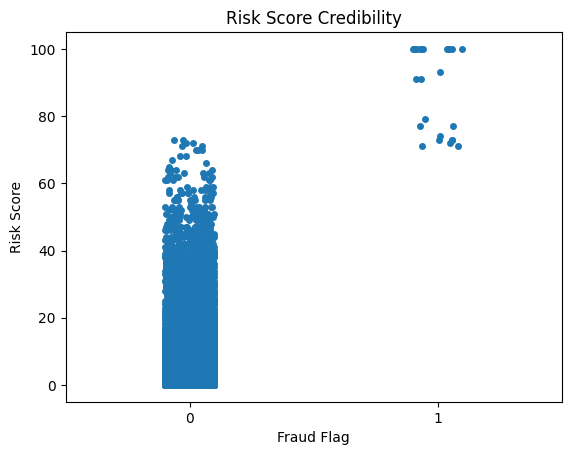

In [13]:
#Is Risk score reliable?
plt.ylabel("Risk Score")
plt.xlabel("Fraud Flag")
plt.title("Risk Score Credibility")
sns.stripplot(x=my_dataset['Fraud_Flag'],y=my_dataset['Risk_Score'])

In [14]:
my_dataset['Transaction_Amount'].corr(my_dataset['Risk_Score'])

np.float64(0.9951575404570748)

In [15]:
my_dataset.groupby('Fraud_Flag')['Risk_Score'].mean()

Fraud_Flag
0    10.182905
1    88.600000
Name: Risk_Score, dtype: float64

The scoring system works but there are many transactions with risk score above 50 which were not flagged. This creates a legitimate tension because frauds may occur on smaller amount but multiple times leaving the risk score below threshold. From the corr function output, its very evident that risk score is essentialy a restatement of how big the transaction is.

# TOP CONTRIBUTORS Of PAKISTAN'S REMITTANCE

<Axes: title={'center': 'Top 5 Countries Sending to Pakistan'}, xlabel='Source Country', ylabel='Number of Transactions'>

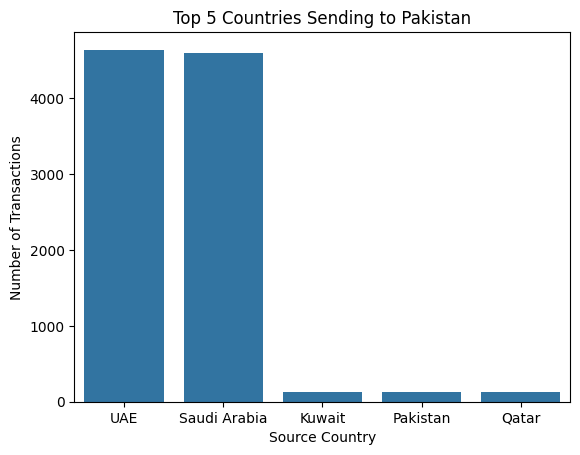

In [16]:
#which foreign countries does the bank need to prioritize on to improve remittance flow to pakistan
pakistan_data=my_dataset[my_dataset['Destination_Country']=='Pakistan']
top_countries=pakistan_data['Source_Country'].value_counts().head()
plt.ylabel("Number of Transactions")
plt.xlabel("Source Country")
plt.title("Top 5 Countries Sending to Pakistan")
sns.barplot(x=top_countries.index,y=top_countries.values)

UAE AND SAUDI ARABIA dominate in the number of remittance transactions to pakistan.
A possible reason to this is UAE AND SAUDI ARABIA host large pakistani expatriate communities many of whom are employed in sectors sucha as construction, engineering, healthcare, retail, and domestic services. These workers send money to support their families in pakistan.


# CUSTOMER DORMANCY

Text(0, 0.5, 'Number of Customers')

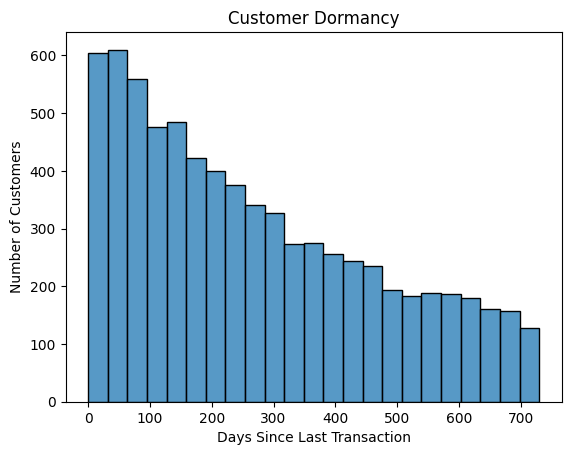

In [17]:
#Are customers actively making transactions?
my_dataset["Transaction_DateTime"] = pd.to_datetime(my_dataset["Transaction_DateTime"])

days_since = (my_dataset["Transaction_DateTime"].max() - my_dataset.groupby("Customer_ID")["Transaction_DateTime"].max()).dt.days

sns.histplot(days_since)

plt.title("Customer Dormancy")
plt.xlabel("Days Since Last Transaction")
plt.ylabel("Number of Customers")


I analyzed how much time had passed since each customer's last transaction to understand customer activity. The results indicate that many customers have not used the bank's services recently. A relatively small portion of customers made transactions in the recent past, while a large share have been inactive for an extended period. This suggests that the bank has a significant number of dormant customers and may need to focus on improving customer retention and encouraging inactive customers to return.

# FURTHER VISUALS

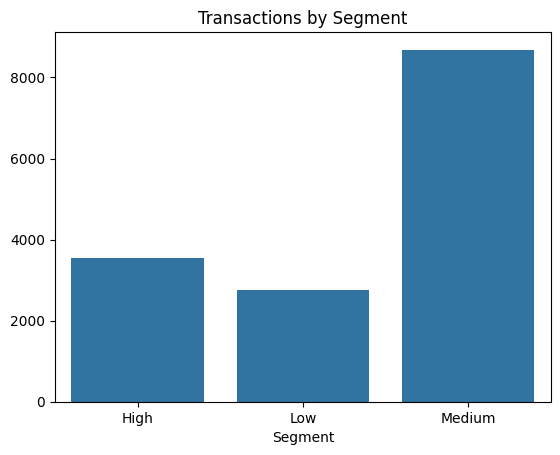

In [18]:
#Customer Segmentation on the basis of transactions made.
counts = my_dataset['Customer_ID'].value_counts()
my_dataset['Segment'] = my_dataset['Customer_ID'].map(
    counts.apply(lambda x: 'Low' if x == 1 else 'Medium' if x <= 3 else 'High')
)
summary = my_dataset.groupby('Segment').size()
sns.barplot(x=summary.index, y=summary.values)
plt.title("Transactions by Segment")
plt.show()

array([[<Axes: title={'center': 'Exchange_Rate'}>,
        <Axes: title={'center': 'Transaction_Amount'}>,
        <Axes: title={'center': 'Converted_Amount'}>],
       [<Axes: title={'center': 'Fee_Charged'}>,
        <Axes: title={'center': 'Tax_Applied'}>,
        <Axes: title={'center': 'Total_Deduction'}>],
       [<Axes: title={'center': 'Processing_Time_Seconds'}>,
        <Axes: title={'center': 'Fraud_Flag'}>,
        <Axes: title={'center': 'AML_Flag'}>],
       [<Axes: title={'center': 'Risk_Score'}>, <Axes: >, <Axes: >]],
      dtype=object)

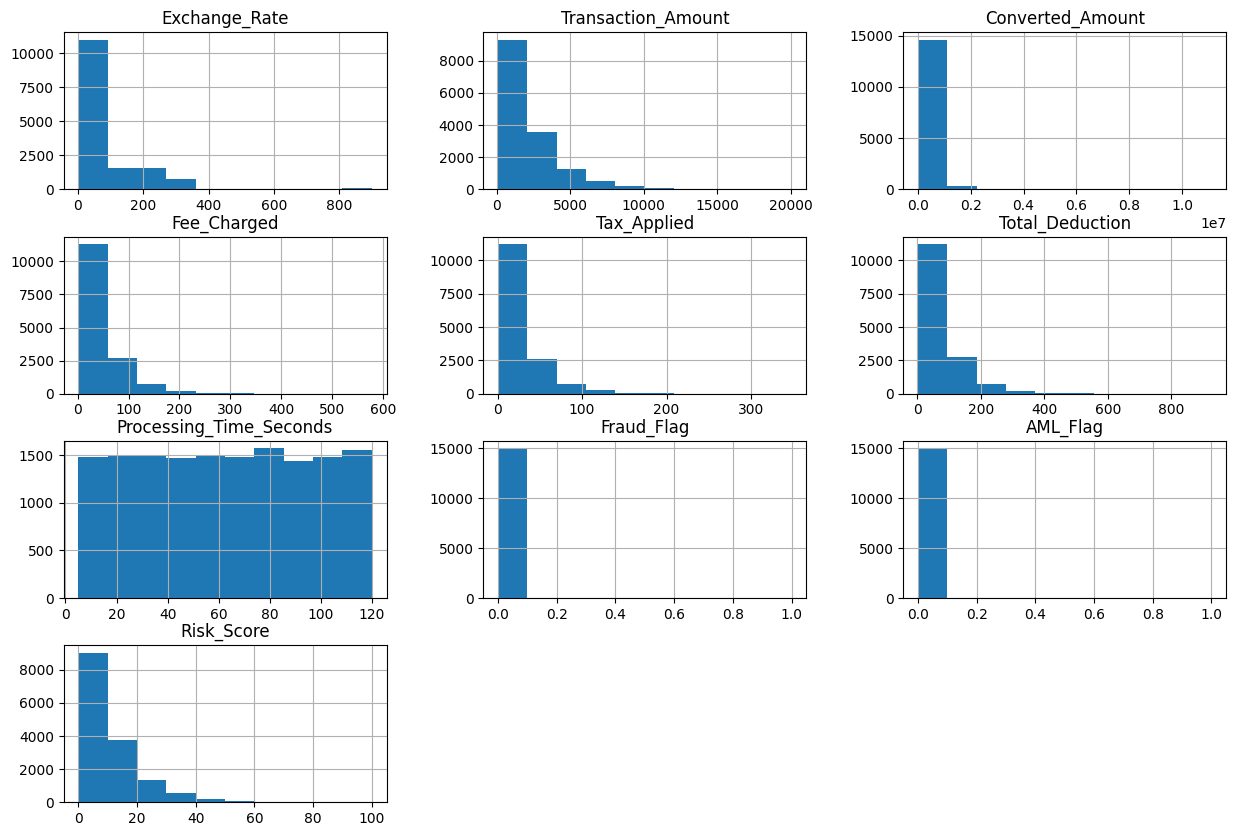

In [19]:
#Histograms for numeric data
numeric_data=my_dataset.select_dtypes(include=['float64','int64'])
numeric_data.hist(figsize=(15,10))  

<Axes: >

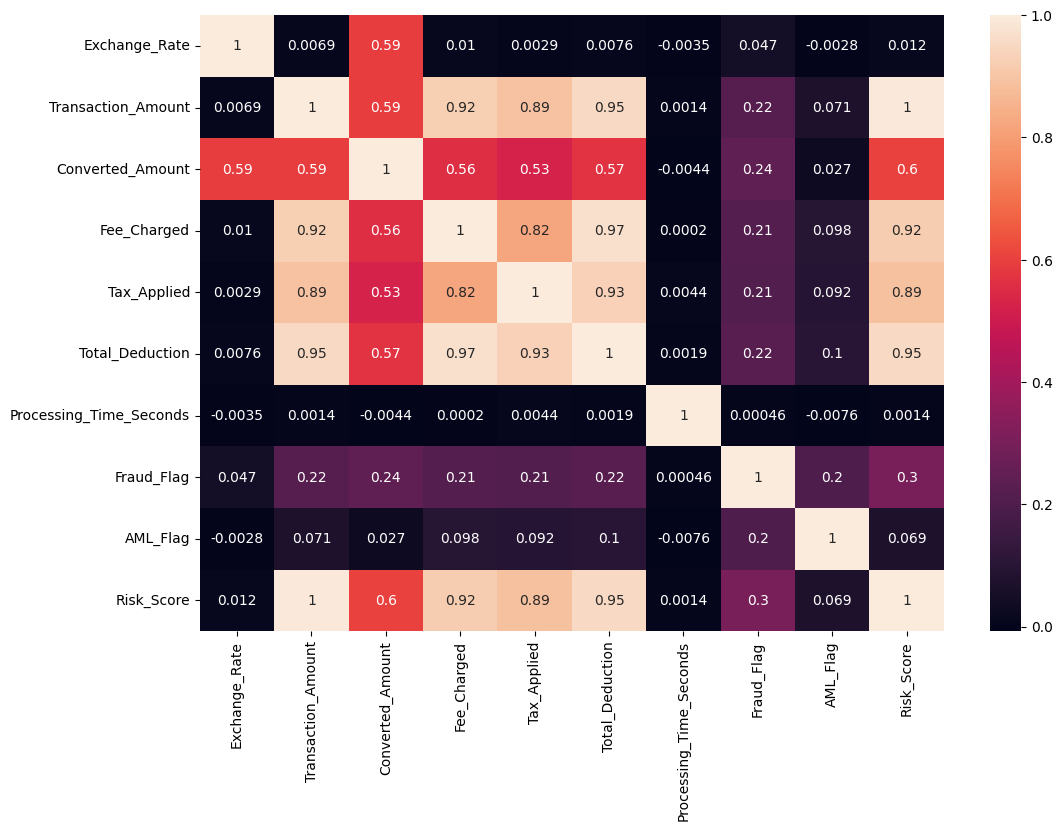

In [20]:
#Heatmap
numeric_matrix=numeric_data.corr()
plt.figure(figsize=(12,8))
sns.heatmap(data=numeric_matrix,annot=True)

## Key Findings

* The dataset contained several columns with missing or constant values that were cleaned before analysis to improve data quality.
* Risk Score showed a meaningful relationship with transaction risk, although some transactions displayed unexpectedly high scores that may require further investigation.
* International remittances were concentrated in a small number of countries, indicating key markets that contribute most to cross-border transactions.
* Customer activity declined over time, with many customers becoming inactive after their most recent transactions, highlighting opportunities for customer re-engagement.
* Overall, the analysis demonstrates how transaction data can be used to identify customer behavior, evaluate operational performance, and support data-driven business decisions.
